In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_csv('cold_source_control_dataset.csv') #calls the data set

**Data cleaning and pre-processing**

In [5]:
df.head()

,Timestamp,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output
0,2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1
1,2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4
2,2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4
3,2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3
4,2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4


In [6]:
df.shape

(3498, 12)

In [7]:
df.describe()

,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Output
count,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000
mean,65.210630,21.525187,26.492562,23.985334,0.761498,65.184674,48.002691,0.087430,2.305269,2.016009
std,19.357733,2.185514,2.922662,2.863748,0.159458,19.619440,6.402203,0.024231,1.698664,1.422792
min,10.000000,15.000000,16.282475,18.000000,0.330000,20.000000,31.092931,0.030000,0.000000,0.000000
25%,51.567063,19.999580,24.500078,21.979872,0.650000,50.937388,43.518808,0.070000,0.950000,1.000000
50%,65.639304,21.524394,26.495368,23.976287,0.760000,65.464146,48.049176,0.090000,1.960000,2.000000
75%,79.528495,23.085253,28.456507,25.918209,0.880000,80.109679,52.339698,0.100000,3.310000,3.000000
max,100.000000,27.965248,35.775612,34.375385,1.110000,100.000000,70.521581,0.160000,10.380000,4.000000


In [8]:
cols = df.columns
print(cols)
print(len(cols))

Index(['Timestamp', 'Server_Workload(%)', 'Inlet_Temperature(°C)',
       'Outlet_Temperature(°C)', 'Ambient_Temperature(°C)',
       'Cooling_Unit_Power_Consumption(kW)', 'Chiller_Usage(%)',
       'AHU_Usage(%)', 'Total_Energy_Cost($)', 'Temperature_Deviation(°C)',
       'Cooling_Strategy_Action', 'Output'],
      dtype='object')
12


In [9]:
print(len(cols))
print(len(cols))
num_cols = df._get_numeric_data().columns
print(num_cols)
print(len(num_cols))

12
12
Index(['Server_Workload(%)', 'Inlet_Temperature(°C)', 'Outlet_Temperature(°C)',
       'Ambient_Temperature(°C)', 'Cooling_Unit_Power_Consumption(kW)',
       'Chiller_Usage(%)', 'AHU_Usage(%)', 'Total_Energy_Cost($)',
       'Temperature_Deviation(°C)', 'Output'],
      dtype='object')
10


In [10]:
non_num_cols = set(cols) - set(num_cols)
print(non_num_cols)

{'Cooling_Strategy_Action', 'Timestamp'}


In [11]:
cols_type = df.dtypes
print(cols_type)

Timestamp                              object
Server_Workload(%)                    float64
Inlet_Temperature(°C)                 float64
Outlet_Temperature(°C)                float64
Ambient_Temperature(°C)               float64
Cooling_Unit_Power_Consumption(kW)    float64
Chiller_Usage(%)                      float64
AHU_Usage(%)                          float64
Total_Energy_Cost($)                  float64
Temperature_Deviation(°C)             float64
Cooling_Strategy_Action                object
Output                                  int64
dtype: object


In [12]:
df.info

<bound method DataFrame.info of                 Timestamp  Server_Workload(%)  Inlet_Temperature(°C)  \
0     2025-01-01 00:00:00          100.000000              24.726323   
1     2025-01-01 01:00:00           87.358993              23.085262   
2     2025-01-01 02:00:00           19.313800              16.288791   
3     2025-01-01 03:00:00           41.406680              19.217280   
4     2025-01-01 04:00:00           49.514889              19.991740   
...                   ...                 ...                    ...   
3493  2025-05-26 13:00:00           66.295603              22.909311   
3494  2025-05-26 14:00:00           74.390242              21.284547   
3495  2025-05-26 15:00:00           80.768533              22.457125   
3496  2025-05-26 16:00:00           74.088522              21.278572   
3497  2025-05-26 17:00:00           27.628318              17.750417   

      Outlet_Temperature(°C)  Ambient_Temperature(°C)  \
0                  28.469324                21

In [13]:
df.isnull().sum()

Timestamp                             0
Server_Workload(%)                    0
Inlet_Temperature(°C)                 0
Outlet_Temperature(°C)                0
Ambient_Temperature(°C)               0
Cooling_Unit_Power_Consumption(kW)    0
Chiller_Usage(%)                      0
AHU_Usage(%)                          0
Total_Energy_Cost($)                  0
Temperature_Deviation(°C)             0
Cooling_Strategy_Action               0
Output                                0
dtype: int64

In [14]:
num_cols_df = df._get_numeric_data()
median_values = num_cols_df.median(numeric_only=True)
print(median_values)

Server_Workload(%)                    65.639304
Inlet_Temperature(°C)                 21.524394
Outlet_Temperature(°C)                26.495368
Ambient_Temperature(°C)               23.976287
Cooling_Unit_Power_Consumption(kW)     0.760000
Chiller_Usage(%)                      65.464146
AHU_Usage(%)                          48.049176
Total_Energy_Cost($)                   0.090000
Temperature_Deviation(°C)              1.960000
Output                                 2.000000
dtype: float64


In [15]:
mean_values = num_cols_df.mean(numeric_only=True)
print(mean_values)

Server_Workload(%)                    65.210630
Inlet_Temperature(°C)                 21.525187
Outlet_Temperature(°C)                26.492562
Ambient_Temperature(°C)               23.985334
Cooling_Unit_Power_Consumption(kW)     0.761498
Chiller_Usage(%)                      65.184674
AHU_Usage(%)                          48.002691
Total_Energy_Cost($)                   0.087430
Temperature_Deviation(°C)              2.305269
Output                                 2.016009
dtype: float64


In [16]:
standard_div_values = num_cols_df.std(numeric_only=True)
print(standard_div_values)

Server_Workload(%)                    19.357733
Inlet_Temperature(°C)                  2.185514
Outlet_Temperature(°C)                 2.922662
Ambient_Temperature(°C)                2.863748
Cooling_Unit_Power_Consumption(kW)     0.159458
Chiller_Usage(%)                      19.619440
AHU_Usage(%)                           6.402203
Total_Energy_Cost($)                   0.024231
Temperature_Deviation(°C)              1.698664
Output                                 1.422792
dtype: float64


In [17]:
corr = num_cols_df.corr()
corr

,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Output
Server_Workload(%),1.000000,0.884864,0.646842,-0.035108,0.935136,0.956171,-0.029674,0.700178,0.003274,-0.017488
Inlet_Temperature(°C),0.884864,1.000000,0.733550,-0.025846,0.829043,0.847400,-0.024958,0.621228,-0.000339,-0.018975
Outlet_Temperature(°C),0.646842,0.733550,1.000000,-0.025262,0.603391,0.619895,-0.033732,0.459915,0.010517,-0.013820
Ambient_Temperature(°C),-0.035108,-0.025846,-0.025262,1.000000,0.149370,-0.030822,0.893500,0.115075,0.032253,-0.002731
Cooling_Unit_Power_Consumption(kW),0.935136,0.829043,0.603391,0.149370,1.000000,0.979438,0.178283,0.750704,0.007107,-0.018218
Chiller_Usage(%),0.956171,0.847400,0.619895,-0.030822,0.979438,1.000000,-0.023080,0.735410,0.002627,-0.016643
AHU_Usage(%),-0.029674,-0.024958,-0.033732,0.893500,0.178283,-0.023080,1.000000,0.133571,0.021255,-0.009582
Total_Energy_Cost($),0.700178,0.621228,0.459915,0.115075,0.750704,0.735410,0.133571,1.000000,0.019551,-0.000797
Temperature_Deviation(°C),0.003274,-0.000339,0.010517,0.032253,0.007107,0.002627,0.021255,0.019551,1.000000,-0.023042
Output,-0.017488,-0.018975,-0.013820,-0.002731,-0.018218,-0.016643,-0.009582,-0.000797,-0.023042,1.000000


In [18]:
target = [col for col in corr.columns if 'Cooling_Unit_Power_Consumption(kW)' in col]

if target:
    seed_corr = corr[target[0]].sort_values(ascending=False)
    print(seed_corr)
else:
    print("Cooling_Unit_Power_Consumption(kW) column not found.")

Cooling_Unit_Power_Consumption(kW)    1.000000
Chiller_Usage(%)                      0.979438
Server_Workload(%)                    0.935136
Inlet_Temperature(°C)                 0.829043
Total_Energy_Cost($)                  0.750704
Outlet_Temperature(°C)                0.603391
AHU_Usage(%)                          0.178283
Ambient_Temperature(°C)               0.149370
Temperature_Deviation(°C)             0.007107
Output                               -0.018218
Name: Cooling_Unit_Power_Consumption(kW), dtype: float64


In [19]:
df.nunique()

Timestamp                             3498
Server_Workload(%)                    3346
Inlet_Temperature(°C)                 3497
Outlet_Temperature(°C)                3498
Ambient_Temperature(°C)               3424
Cooling_Unit_Power_Consumption(kW)      79
Chiller_Usage(%)                      3307
AHU_Usage(%)                          3498
Total_Energy_Cost($)                    14
Temperature_Deviation(°C)              624
Cooling_Strategy_Action                  5
Output                                   5
dtype: int64

In [20]:
counts = df.nunique()
to_del = [i for i,v in enumerate(counts) if (float(v)/df.shape[0]*100)<1]
print(to_del)

[8, 10, 11]


In [21]:
dups = df.duplicated()
print(dups.any())
print(df[dups])

False
Empty DataFrame
Columns: [Timestamp, Server_Workload(%), Inlet_Temperature(°C), Outlet_Temperature(°C), Ambient_Temperature(°C), Cooling_Unit_Power_Consumption(kW), Chiller_Usage(%), AHU_Usage(%), Total_Energy_Cost($), Temperature_Deviation(°C), Cooling_Strategy_Action, Output]
Index: []


In [22]:
num_df = df._get_numeric_data()

In [23]:
corr = num_df.corr()

Text(0.5, 1.0, 'Data Center Heat Map')

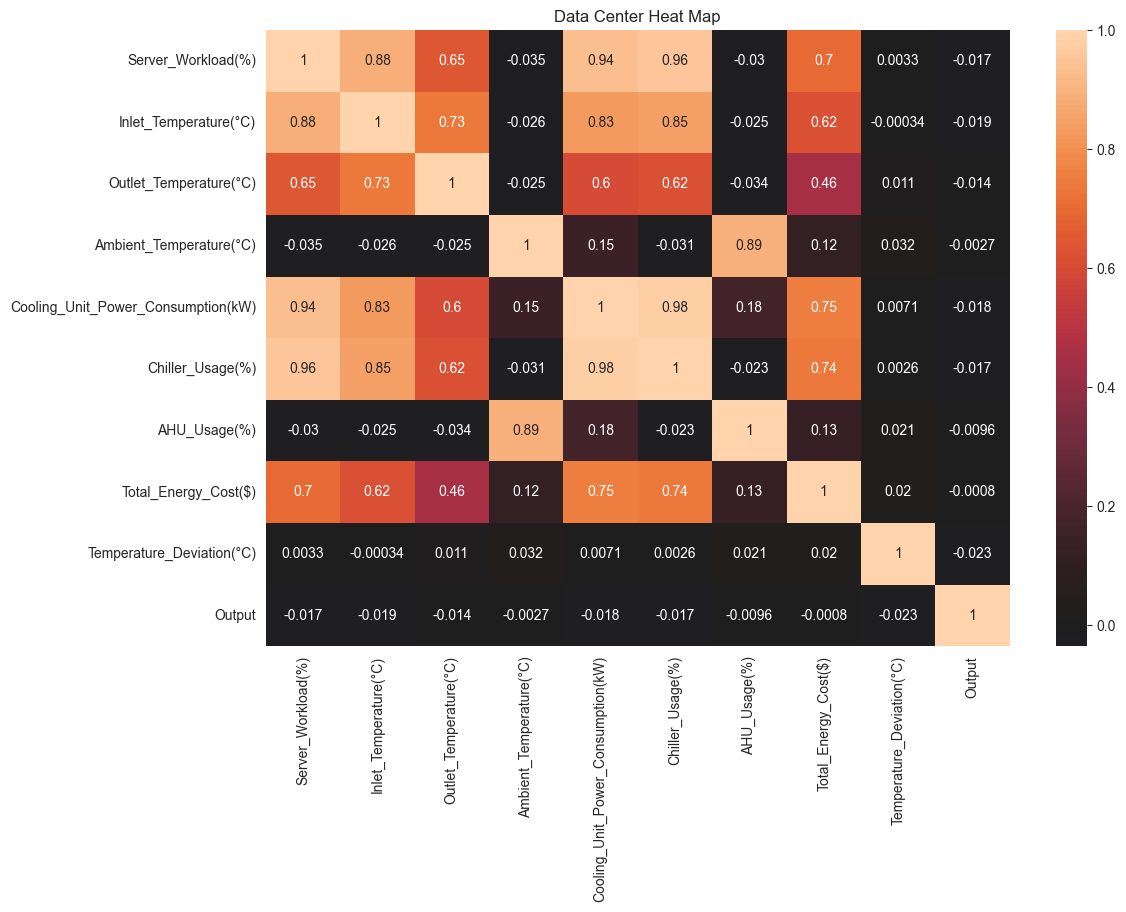

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, center=0.0)
plt.title("Data Center Heat Map")

In [25]:
invalid_workload = ((df["Server_Workload(%)"] < 0) | (df["Server_Workload(%)"] > 100)).sum()
print(invalid_workload)

0


In [26]:
invalid_cooling = (df["Cooling_Unit_Power_Consumption(kW)"] <= 0).sum()
print(invalid_cooling)

0


In [27]:
invalid_Chiller_Usage = ((df["Chiller_Usage(%)"] < 0) | (df["Chiller_Usage(%)"] > 100)).sum()
print(invalid_Chiller_Usage)

0


In [28]:
invalid_Chiller_Usage = ((df["Chiller_Usage(%)"] < 0) | (df["Chiller_Usage(%)"] > 100)).sum()
print(invalid_Chiller_Usage)

0


In [29]:
invalid_AHU_Usage = ((df["AHU_Usage(%)"] < 0) | (df["AHU_Usage(%)"] > 100)).sum()
print(invalid_AHU_Usage)

0


In [30]:
invalid_Total_Energy_Cost = (df["Total_Energy_Cost($)"] <= 0).sum()
print(invalid_Total_Energy_Cost)

0


In [31]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
time_diffs = df['Timestamp'].diff().value_counts()
print(time_diffs)

Timestamp
0 days 01:00:00    3497
Name: count, dtype: int64


Text(0.5, 1.0, "Look for 'Ghost' zeros or extreme spikes")

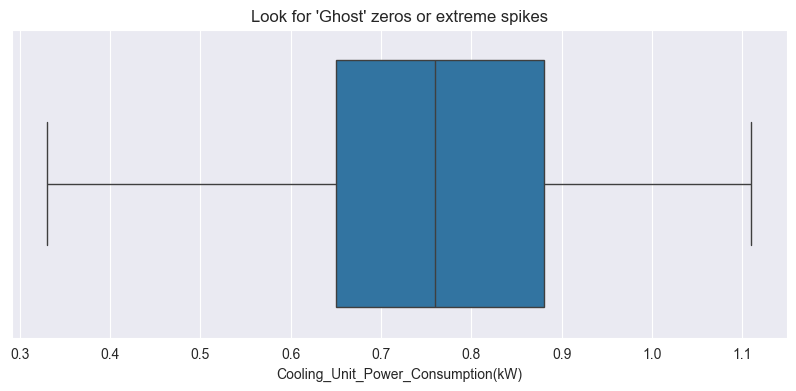

In [32]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Cooling_Unit_Power_Consumption(kW)'])
plt.title("Look for 'Ghost' zeros or extreme spikes")

In [22]:
physics_errors_1= (df['Outlet_Temperature(°C)'] < df['Inlet_Temperature(°C)']).sum()
print(f"outlet less: {physics_errors_1}")
physics_errors_2= (df['Outlet_Temperature(°C)'] == df['Inlet_Temperature(°C)']).sum()
print(f"outlet equal: {physics_errors_2}")
#this is an anomaly so should be removed

outlet less: 0
outlet equal: 21


In [34]:
physics_errors_2 = df[df['Outlet_Temperature(°C)'] == df['Inlet_Temperature(°C)']]

In [35]:
print("Audit of 21 Equal Temperature Rows:")
print(physics_errors_2[['Server_Workload(%)', 'Cooling_Unit_Power_Consumption(kW)']].describe())
#this is to make sure that it is an anomaly

Audit of 21 Equal Temperature Rows:
       Server_Workload(%)  Cooling_Unit_Power_Consumption(kW)
count           21.000000                           21.000000
mean            70.009839                            0.820952
std             16.169896                            0.136011
min             42.877547                            0.510000
25%             58.692886                            0.730000
50%             73.436654                            0.860000
75%             79.793489                            0.940000
max             92.869026                            0.970000


In [36]:
high_load_errors = (physics_errors_2['Server_Workload(%)'] > 10).sum()
print(f"\nRows with >10% Workload but ZERO heat increase: {high_load_errors}")


Rows with >10% Workload but ZERO heat increase: 21


In [37]:
df.shape

(3498, 12)

In [38]:
print(21/3498)

0.006003430531732418


In [123]:
sns.countplot(data=df, x='Cooling_Strategy_Action')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("Cooling_Strategy_Action.png", dpi=300, bbox_inches="tight")
plt.close()

In [122]:
sns.histplot(df['Cooling_Unit_Power_Consumption(kW)'], kde=True)

plt.tight_layout()
plt.savefig("Cooling_Unit_Power_Consumption(kW).png", dpi=300, bbox_inches="tight")
plt.close()

In [41]:
df_cleaned = df[df['Outlet_Temperature(°C)'] > df['Inlet_Temperature(°C)']].copy()
#this way I drop all the anomaly rows and create a clean df

In [42]:
print(f"Original rows: {len(df)}")

Original rows: 3498


In [43]:
print(f"Cleaned rows: {len(df_cleaned)}")

Cleaned rows: 3477


In [44]:
print(f"Rows removed: {len(df) - len(df_cleaned)}")

Rows removed: 21


In [45]:
df_cleaned.shape

(3477, 12)

In [46]:
df_cleaned.to_csv('cleaned_cold_source_control_dataset.csv', index=False)

In [47]:
df_new = pd.read_csv("cleaned_cold_source_control_dataset.csv")


In [48]:
df_new.head()

,Timestamp,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output
0,2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1
1,2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4
2,2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4
3,2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3
4,2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4


In [49]:
df_new.shape

(3477, 12)

**Feature engineering**

In [52]:
it_power_max = 3.0
df_new["IT_Power_Consumption(kW)"] = (df_new["Server_Workload(%)"]/100) * it_power_max

In [53]:
df_new.head()

,Timestamp,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output,IT_Power_Consumption(kW)
0,2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1,3.000000
1,2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4,2.620770
2,2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4,0.579414
3,2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3,1.242200
4,2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4,1.485447


In [54]:
df_new["PUE"] = ((df_new["IT_Power_Consumption(kW)"]+df_new["Cooling_Unit_Power_Consumption(kW)"])/df_new["IT_Power_Consumption(kW)"]).round(2)
#created to get an understanding of the main output of the project and see how it acts

In [55]:
df_new.head()

,Timestamp,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output,IT_Power_Consumption(kW),PUE
0,2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1,3.000000,1.33
1,2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4,2.620770,1.36
2,2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4,0.579414,1.74
3,2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3,1.242200,1.49
4,2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4,1.485447,1.46


In [56]:
df_new['PUE'].describe()

count    3477.000000
mean        1.408674
std         0.095880
min         1.300000
25%         1.360000
50%         1.390000
75%         1.430000
max         2.500000
Name: PUE, dtype: float64

In [57]:
df_new["IT_Power_Cost"] = df_new["IT_Power_Consumption(kW)"]*df_new["Total_Energy_Cost($)"]
#one more output created for the same reason as PUE

In [58]:
df_new.head()

,Timestamp,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output,IT_Power_Consumption(kW),PUE,IT_Power_Cost
0,2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1,3.000000,1.33,0.270000
1,2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4,2.620770,1.36,0.262077
2,2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4,0.579414,1.74,0.034765
3,2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3,1.242200,1.49,0.099376
4,2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4,1.485447,1.46,0.148545


In [59]:
df_new["Total_cost"] = (df_new["IT_Power_Consumption(kW)"]+df_new["Cooling_Unit_Power_Consumption(kW)"])*df_new["Total_Energy_Cost($)"]

In [60]:
df_new.head()

,Timestamp,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output,IT_Power_Consumption(kW),PUE,IT_Power_Cost,Total_cost
0,2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1,3.000000,1.33,0.270000,0.358200
1,2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4,2.620770,1.36,0.262077,0.357077
2,2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4,0.579414,1.74,0.034765,0.060565
3,2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3,1.242200,1.49,0.099376,0.148176
4,2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4,1.485447,1.46,0.148545,0.217545


In [61]:
df_new["Added_Cooling_Cost"] = df_new["Total_cost"] - df_new["IT_Power_Cost"]

In [62]:
df_new.head()

,Timestamp,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output,IT_Power_Consumption(kW),PUE,IT_Power_Cost,Total_cost,Added_Cooling_Cost
0,2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1,3.000000,1.33,0.270000,0.358200,0.0882
1,2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4,2.620770,1.36,0.262077,0.357077,0.0950
2,2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4,0.579414,1.74,0.034765,0.060565,0.0258
3,2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3,1.242200,1.49,0.099376,0.148176,0.0488
4,2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4,1.485447,1.46,0.148545,0.217545,0.0690


In [63]:
strategy_price_map = df_new.groupby('Cooling_Strategy_Action')['Total_Energy_Cost($)'].mean().to_dict()
strategy_risk_map = df_new.groupby('Cooling_Strategy_Action')['Total_Energy_Cost($)'].std().to_dict()

In [64]:
print("Strategy-Based Financial Context (Mean):")
for strategy, price in strategy_price_map.items():
    risk = strategy_risk_map[strategy]
    print(f"- {strategy}: ${price:.4f}/kWh (Risk/Volatility: ±${risk:.4f})")
#for the cost feature of the system to add the correct pricing for each cooling strategy

Strategy-Based Financial Context (Mean):
- Boost All: $0.0855/kWh (Risk/Volatility: ±$0.0241)
- Eco Mode: $0.0890/kWh (Risk/Volatility: ±$0.0248)
- Increase Chiller: $0.0880/kWh (Risk/Volatility: ±$0.0237)
- Maintain: $0.0871/kWh (Risk/Volatility: ±$0.0244)
- Reduce AHU: $0.0875/kWh (Risk/Volatility: ±$0.0241)


In [65]:
df_new["DT"] = df_new['Outlet_Temperature(°C)']-df_new['Inlet_Temperature(°C)']

In [66]:
df_new.head()

,Timestamp,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output,IT_Power_Consumption(kW),PUE,IT_Power_Cost,Total_cost,Added_Cooling_Cost,DT
0,2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1,3.000000,1.33,0.270000,0.358200,0.0882,3.743001
1,2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4,2.620770,1.36,0.262077,0.357077,0.0950,6.769102
2,2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4,0.579414,1.74,0.034765,0.060565,0.0258,7.093055
3,2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3,1.242200,1.49,0.099376,0.148176,0.0488,5.106418
4,2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4,1.485447,1.46,0.148545,0.217545,0.0690,3.213803


In [67]:
df_new['DT'].describe()

count    3477.000000
mean        4.997376
std         1.954781
min         0.002374
25%         3.650305
50%         4.971318
75%         6.326500
max        11.673549
Name: DT, dtype: float64

In [121]:
num_df = df_new._get_numeric_data()
corr = num_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, center=0.0)
plt.title("Data Center Heat Map")

plt.tight_layout()
plt.savefig("Data_Center_Heat_Map.png", dpi=300, bbox_inches="tight")
plt.close()

In [69]:
df_new.select_dtypes(include=["number"]).corr()["DT"].sort_values(ascending=False)

DT                                    1.000000
Outlet_Temperature(°C)                0.659622
Temperature_Deviation(°C)             0.016634
Output                                0.008136
PUE                                   0.002304
Total_Energy_Cost($)                 -0.007142
Ambient_Temperature(°C)              -0.007312
Added_Cooling_Cost                   -0.012575
Total_cost                           -0.013889
IT_Power_Cost                        -0.014253
Chiller_Usage(%)                     -0.015681
Inlet_Temperature(°C)                -0.016366
IT_Power_Consumption(kW)             -0.018484
Server_Workload(%)                   -0.018484
AHU_Usage(%)                         -0.018677
Cooling_Unit_Power_Consumption(kW)   -0.019129
Name: DT, dtype: float64

In [70]:
df_new.select_dtypes(include=["number"]).corr()["Temperature_Deviation(°C)"].sort_values(ascending=False)

Temperature_Deviation(°C)             1.000000
Ambient_Temperature(°C)               0.031464
Total_Energy_Cost($)                  0.020924
AHU_Usage(%)                          0.020341
DT                                    0.016634
Added_Cooling_Cost                    0.016131
Total_cost                            0.010847
Outlet_Temperature(°C)                0.010495
IT_Power_Cost                         0.009014
Cooling_Unit_Power_Consumption(kW)    0.007542
PUE                                   0.005658
Server_Workload(%)                    0.003631
IT_Power_Consumption(kW)              0.003631
Chiller_Usage(%)                      0.003266
Inlet_Temperature(°C)                -0.000907
Output                               -0.024373
Name: Temperature_Deviation(°C), dtype: float64

In [71]:
df_new.select_dtypes(include=["number"]).corr()["Outlet_Temperature(°C)"].sort_values(ascending=False)


Outlet_Temperature(°C)                1.000000
Inlet_Temperature(°C)                 0.740701
DT                                    0.659622
IT_Power_Consumption(kW)              0.652940
Server_Workload(%)                    0.652940
Chiller_Usage(%)                      0.626663
Cooling_Unit_Power_Consumption(kW)    0.610683
IT_Power_Cost                         0.590986
Total_cost                            0.582569
Added_Cooling_Cost                    0.547826
Total_Energy_Cost($)                  0.462740
Temperature_Deviation(°C)             0.010495
Output                               -0.009542
Ambient_Temperature(°C)              -0.024194
AHU_Usage(%)                         -0.031267
PUE                                  -0.449407
Name: Outlet_Temperature(°C), dtype: float64

**Model Training and selection**

In [72]:
from sklearn.model_selection import train_test_split

features = ["Cooling_Strategy_Action", "Server_Workload(%)", "Inlet_Temperature(°C)","Ambient_Temperature(°C)"]

df_model = df_new.dropna(subset=['Cooling_Unit_Power_Consumption(kW)','Outlet_Temperature(°C)'])
x = df_model[features]

yc = df_model["Cooling_Unit_Power_Consumption(kW)"]
ydt = df_model["Outlet_Temperature(°C)"]

x_train, x_test, yc_train, yc_test, ydt_train, ydt_test = train_test_split(x, yc, ydt, test_size=0.2, random_state=42)

#split the data set the train will be used for the kfoldCV with the default parameters as validation and the test for the final tuned models

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error

cat_cols = ['Cooling_Strategy_Action']

num_cols = ['Server_Workload(%)','Inlet_Temperature(°C)','Ambient_Temperature(°C)']

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ("num", StandardScaler(),num_cols)
    ]
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scorring = {
    "rmse": make_scorer(rmse),
    "mae": 'neg_mean_absolute_error',
    "r2": 'r2'
}

#created the preprocessor for each pipeline and the CV with 5 folds and true for shuffle

In [74]:
#this is the training for the ridge model and its pipeline for both the outputs wanted.
from sklearn.linear_model import Ridge
ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_model_c = cross_validate(
    ridge_pipe,
    x_train,
    yc_train,
    cv=cv,
    scoring=scorring,
    return_train_score=True
)

print("\nRidge Model for cooling:")
print("Train RMSE:", ridge_model_c["train_rmse"].mean())
print("Val RMSE:", ridge_model_c["test_rmse"].mean())
print("val_RMSE per fold", ridge_model_c["test_rmse"])
train_rmse = ridge_model_c["train_rmse"].mean()
val_rmse = ridge_model_c["test_rmse"].mean()
gap = val_rmse - train_rmse
print("train_val_gap", gap)
print("Val RMSE std:", ridge_model_c["test_rmse"].std())
print("Val MAE:", -ridge_model_c["test_mae"].mean())
print("Val R2:", ridge_model_c["test_r2"].mean())

ridge_model_DT = cross_validate(
    ridge_pipe,
    x_train,
    ydt_train,
    cv=cv,
    scoring=scorring,
    return_train_score=True
)

print("\nRidge Model for outlet temperature:")
print("Train RMSE:", ridge_model_DT["train_rmse"].mean())
print("Val RMSE:", ridge_model_DT["test_rmse"].mean())
print("val_RMSE per fold", ridge_model_DT["test_rmse"])
train_rmse = ridge_model_DT["train_rmse"].mean()
val_rmse = ridge_model_DT["test_rmse"].mean()
gap = val_rmse - train_rmse
print("train_val_gap", gap)
print("Val RMSE std:", ridge_model_DT["test_rmse"].std())
print("Val MAE:", -ridge_model_DT["test_mae"].mean())
print("Val R2:", ridge_model_DT["test_r2"].mean())


Ridge Model for cooling:
Train RMSE: 0.04844879990850955
Val RMSE: 0.048594059957448824
val_RMSE per fold [0.04920982 0.04820269 0.04929833 0.04879994 0.04745952]
train_val_gap 0.00014526004893927053
Val RMSE std: 0.0006867144986395511
Val MAE: 0.04143868520169887
Val R2: 0.9075563780951464

Ridge Model for outlet temperature:
Train RMSE: 1.9506461273300466
Val RMSE: 1.9590722247215475
val_RMSE per fold [1.92657806 1.90818853 2.00115104 2.01565509 1.94378841]
train_val_gap 0.008426097391500909
Val RMSE std: 0.042073420998113384
Val MAE: 1.5829852025057483
Val R2: 0.5409220849611689


/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_

In [75]:
#this is the training for the BayesianRidge model and its pipeline for both the outputs wanted.
from sklearn.linear_model import BayesianRidge
BayesianRidge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", BayesianRidge())
])

BayesianRidge_model_c = cross_validate(
    BayesianRidge_pipe,
    x_train,
    yc_train,
    cv=cv,
    scoring=scorring,
    return_train_score=True
)

print("\nBayesian Ridge Model for cooling:")
print("Train RMSE:", BayesianRidge_model_c["train_rmse"].mean())
print("Val RMSE:", BayesianRidge_model_c["test_rmse"].mean())
print("val_RMSE per fold", BayesianRidge_model_c["test_rmse"])
train_rmse = BayesianRidge_model_c["train_rmse"].mean()
val_rmse = BayesianRidge_model_c["test_rmse"].mean()
gap = val_rmse - train_rmse
print("Val RMSE std:", BayesianRidge_model_c["test_rmse"].std())
print("Val MAE:", -BayesianRidge_model_c["test_mae"].mean())
print("Val R2:", BayesianRidge_model_c["test_r2"].mean())

BayesianRidge_model_DT = cross_validate(
    BayesianRidge_pipe,
    x_train,
    ydt_train,
    cv=cv,
    scoring=scorring,
    return_train_score=True
)

print("\nBayesianRidge Model for outlet temperature:")
print("Train RMSE:", BayesianRidge_model_DT["train_rmse"].mean())
print("Val RMSE:", BayesianRidge_model_DT["test_rmse"].mean())
print("val_RMSE per fold", BayesianRidge_model_DT["test_rmse"])
train_rmse = BayesianRidge_model_DT["train_rmse"].mean()
val_rmse = BayesianRidge_model_DT["test_rmse"].mean()
gap = val_rmse - train_rmse
print("train_val_gap", gap)
print("Val RMSE std:", BayesianRidge_model_DT["test_rmse"].std())
print("Val MAE:", -BayesianRidge_model_DT["test_mae"].mean())
print("Val R2:", BayesianRidge_model_DT["test_r2"].mean())



Bayesian Ridge Model for cooling:
Train RMSE: 0.04844869557262331
Val RMSE: 0.0485940510369247
val_RMSE per fold [0.04920977 0.04820243 0.04930088 0.0488001  0.04745708]
Val RMSE std: 0.000688075220529657
Val MAE: 0.04143816284186154
Val R2: 0.9075561736503716

BayesianRidge Model for outlet temperature:
Train RMSE: 1.950681599072849
Val RMSE: 1.9590830154418968
val_RMSE per fold [1.92727071 1.90770624 2.00134362 2.01530661 1.94378789]
train_val_gap 0.008401416369047787
Val RMSE std: 0.04202995948863208
Val MAE: 1.5831330118047338
Val R2: 0.5409148965579204


/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelo

In [76]:
#this is the training for the XGBRegressor model and its pipeline for both the outputs wanted.
from xgboost import XGBRegressor

XGB_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(booster='gblinear', objective='reg:squarederror', random_state=42))
])

XGB_model_c = cross_validate(
    XGB_pipe,
    x_train,
    yc_train,
    cv=cv,
    scoring=scorring,
    return_train_score=True
)

print("\nXGB Model for cooling:")
print("Train RMSE:", XGB_model_c["train_rmse"].mean())
print("Val RMSE:", XGB_model_c["test_rmse"].mean())
print("val_RMSE per fold", XGB_model_c["test_rmse"])
train_rmse = XGB_model_c["train_rmse"].mean()
val_rmse = XGB_model_c["test_rmse"].mean()
gap = val_rmse - train_rmse
print("train_val_gap", gap)
print("Val RMSE std:", XGB_model_c["test_rmse"].std())
print("Val MAE:", -XGB_model_c["test_mae"].mean())
print("Val R2:", XGB_model_c["test_r2"].mean())

XGB_model_DT = cross_validate(
    XGB_pipe,
    x_train,
    ydt_train,
    cv=cv,
    scoring=scorring,
    return_train_score=True
)

print("\nXGB Model for outlet temperature:")
print("Train RMSE:", XGB_model_DT["train_rmse"].mean())
print("Val RMSE:", XGB_model_DT["test_rmse"].mean())
print("val_RMSE per fold", XGB_model_DT["test_rmse"])
train_rmse = XGB_model_DT["train_rmse"].mean()
val_rmse = XGB_model_DT["test_rmse"].mean()
gap = val_rmse - train_rmse
print("train_val_gap", gap)
print("val RMSE std:", XGB_model_DT["test_rmse"].std())
print("val MAE:", -XGB_model_DT["test_mae"].mean())
print("val R2:", XGB_model_DT["test_r2"].mean())



XGB Model for cooling:
Train RMSE: 0.048448624846416655
Val RMSE: 0.04859421643392575
val_RMSE per fold [0.0492101  0.04820144 0.04930432 0.04880091 0.04745431]
train_val_gap 0.0001455915875090974
Val RMSE std: 0.0006899196786025442
Val MAE: 0.04143769754930635
Val R2: 0.9075552170547914

XGB Model for outlet temperature:
Train RMSE: 1.9506451268919627
Val RMSE: 1.9590760405794057
val_RMSE per fold [1.92650192 1.90827648 2.00111996 2.01571566 1.94376619]
train_val_gap 0.008430913687442976
val RMSE std: 0.04207564025081662
val MAE: 1.5829684732811742
val R2: 0.5409202663794479


In [77]:
#this is the training for the NN model and its pipeline for both the outputs wanted.
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from skorch import NeuralNetRegressor
from skorch.callbacks import InputShapeSetter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

sample_transformed = preprocessor.fit_transform(x_train.iloc[:5])
actual_input_dim = sample_transformed.shape[1]

class NN(nn.Module):
    def __init__(self, input_dim=1):
        super(NN, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.layer(x.float()).squeeze(-1)

NN_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', NeuralNetRegressor(
        NN,
        max_epochs=150,
        lr=0.01,
        optimizer=optim.Adam,
        verbose=0,
        train_split=None,
        callbacks=[InputShapeSetter(param_name="input_dim")],
    ))
])

yc_train_f = yc_train.to_numpy(dtype=np.float32)
ydt_train_f = ydt_train.to_numpy(dtype=np.float32)

NN_model_c = cross_validate(
    NN_pipe,
    x_train,
    yc_train_f,
    cv=cv,
    scoring=scorring,
    return_train_score=True
)

print("\nNN Model for cooling:")
print("Train RMSE:", NN_model_c["train_rmse"].mean())
print("Val RMSE:", NN_model_c["test_rmse"].mean())
print("val_RMSE per fold", NN_model_c["test_rmse"])
train_rmse = NN_model_c["train_rmse"].mean()
val_rmse = NN_model_c["test_rmse"].mean()
gap = val_rmse - train_rmse
print("train_val_gap", gap)
print("Val RMSE std:", NN_model_c["test_rmse"].std())
print("Val MAE:", -NN_model_c["test_mae"].mean())
print("Val R2:", NN_model_c["test_r2"].mean())

NN_model_dt = cross_validate(
    NN_pipe,
    x_train,
    ydt_train_f,
    cv=cv,
    scoring=scorring,
    return_train_score=True
)
print("\nNN Model for outlet temperature:")
print("Train RMSE:", NN_model_dt["train_rmse"].mean())
print("Val RMSE:", NN_model_dt["test_rmse"].mean())
print("val_RMSE per fold", NN_model_dt["test_rmse"])
train_rmse = NN_model_dt["train_rmse"].mean()
val_rmse = NN_model_dt["test_rmse"].mean()
gap = val_rmse - train_rmse
print("train_val_gap", gap)
print("Val RMSE std:", NN_model_dt["test_rmse"].std())
print("Val MAE:", -NN_model_dt["test_mae"].mean())
print("Val R2:", NN_model_dt["test_r2"].mean())


NN Model for cooling:
Train RMSE: 0.04995464143116164
Val RMSE: 0.05306177157248702
val_RMSE per fold [0.05461766 0.05175238 0.05328055 0.04955328 0.05610498]
train_val_gap 0.0031071301413253746
Val RMSE std: 0.0022695286723928266
Val MAE: 0.04439086690545082
Val R2: 0.8893762946128845

NN Model for outlet temperature:
Train RMSE: 1.954569237355166
Val RMSE: 2.0256953886645177
val_RMSE per fold [1.97031092 1.95973229 2.07519933 2.11679637 2.00643803]
train_val_gap 0.07112615130935174
Val RMSE std: 0.06089243543664911
Val MAE: 1.6424481630325318
Val R2: 0.5092374801635742


will use the ridge model since they all perform relatively identically and the ridge model is the most simplistic one

In [78]:
#gridsearchCV for the Ridge model which performed the best.
from sklearn.model_selection import GridSearchCV

param_grid = {'model__alpha': [0.1, 0.5, 1.0,2.0,5.0, 10.0, 100.0]}
HP_search_c = GridSearchCV(ridge_pipe, param_grid, cv=cv, scoring='r2')
HP_search_c.fit(x_train, yc_train)
print("\nBest hyperparameters for cooling:")
print(HP_search_c.best_params_)


Best hyperparameters for cooling:
{'model__alpha': 0.5}


/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_

In [79]:
HP_search_dt = GridSearchCV(ridge_pipe, param_grid, cv=cv, scoring='r2')
HP_search_dt.fit(x_train, ydt_train)
print("\nBest hyperparameters for outlet temperature    :")
print(HP_search_dt.best_params_)

/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_


Best hyperparameters for outlet temperature    :
{'model__alpha': 2.0}


/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_

In [80]:
#the final model for the fist output (cooling)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

best_alpha_c = 0.5

final_ridge_model_c = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=best_alpha_c))
])
final_ridge_model_c.fit(x_train, yc_train)

train_preds_c = final_ridge_model_c.predict(x_train)
test_preds_c = final_ridge_model_c.predict(x_test)

train_rmse = np.sqrt(mean_squared_error(yc_train, train_preds_c))
train_r2 = r2_score(yc_train, train_preds_c)
test_rmse = np.sqrt(mean_squared_error(yc_test, test_preds_c))
test_mae = mean_absolute_error(yc_test, test_preds_c)
test_r2 = r2_score(yc_test, test_preds_c)

print("HP ridge for cooling on unseen data")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f} ")
gap = test_rmse - train_rmse
print(f"Train-Test Gap: {gap:.4f}")
print(f"Test MAE:   {test_mae:.4f}")
print(f"Test R2:    {test_r2:.4f}")



HP ridge for cooling on unseen data
Train RMSE: 0.0485
Test RMSE:  0.0482 
Train-Test Gap: -0.0002
Test MAE:   0.0412
Test R2:    0.9053


/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_

In [84]:
plt.figure(figsize=(8, 6))
plt.scatter(yc_train, train_preds_c, alpha=0.7)

min_val = min(np.min(yc_train), np.min(train_preds_c))
max_val = max(np.max(yc_train), np.max(train_preds_c))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Cooling Power")
plt.ylabel("Predicted Cooling Power")
plt.title("Ridge Regression: Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ridge_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.close()

In [86]:
best_alpha_dt = 2.0

final_ridge_model_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=best_alpha_dt))
])
final_ridge_model_dt.fit(x_train, ydt_train)

train_preds_dt = final_ridge_model_dt.predict(x_train)
test_preds_dt = final_ridge_model_dt.predict(x_test)

train_rmse = np.sqrt(mean_squared_error(ydt_train, train_preds_dt))
train_r2 = r2_score(ydt_train, train_preds_dt)
test_rmse = np.sqrt(mean_squared_error(ydt_test, test_preds_dt))
test_mae = mean_absolute_error(ydt_test, test_preds_dt)
test_r2 = r2_score(ydt_test, test_preds_dt)

print("HP ridge for outlet temp on unseen data")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f} ")
gap = test_rmse - train_rmse
print(f"Train-Test Gap: {gap:.4f}")
print(f"Test MAE:   {test_mae:.4f}")
print(f"Test R2:    {test_r2:.4f}")


HP ridge for outlet temp on unseen data
Train RMSE: 1.9516
Test RMSE:  1.9650 
Train-Test Gap: 0.0135
Test MAE:   1.5768
Test R2:    0.5584


/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/angelosmichalopoulos/.virtualenvs/.venv/lib/python3.9/site-packages/sklearn/linear_model/_

In [87]:
#the HistGradientBoostingRegressor for the second output (outlet temp)
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

quantiles = [0.1, 0.5, 0.9]
quantile_results = {}

print(f"\n--- Quantile Regression for Outlet Temperature ---")

for q in quantiles:
    quantile_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(
            loss='quantile',
            quantile=q,
            l2_regularization=1.0,
            random_state=42
        ))
    ])
    cv_results = cross_validate(
        quantile_pipe,
        x_train,
        ydt_train,
        cv=cv,
        scoring=scorring,
        return_train_score=True
    )

    quantile_results[q] = cv_results
    print(f"\nResults for {int(q*100)}th Percentile:")
    print(f"Val RMSE: {cv_results['test_rmse'].mean():.4f}")
    print(f"Val MAE: {-cv_results['test_mae'].mean():.4f}")



--- Quantile Regression for Outlet Temperature ---

Results for 10th Percentile:
Val RMSE: 2.9177
Val MAE: 2.3891

Results for 50th Percentile:
Val RMSE: 2.0799
Val MAE: 1.6802

Results for 90th Percentile:
Val RMSE: 2.9480
Val MAE: 2.4489


In [88]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

quantiles = [0.1, 0.5, 0.9]
final_outlet_model = {}
param_grid={
    'model__l2_regularization': [0.1, 1, 5, 10],
    'model__learning_rate': [0.001, 0.01, 0.1, 0.5],
    'model__max_iter': [100,200],
    'model__max_leaf_nodes': [10,15,20]
}

for q in quantiles:
    print('Tuning for ',q)
    quantile_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(loss='quantile', quantile=q, random_state=42))
    ])

    HP_search_dt = GridSearchCV(
        quantile_pipe,
        param_grid,
        cv=cv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    HP_search_dt.fit(x_train, ydt_train)
    print(f"Best hyperparameters for {int(q*100)}th percentile:")
    print(HP_search_dt.best_params_)
    final_outlet_model[q] = HP_search_dt.best_estimator_

Tuning for  0.1
Best hyperparameters for 10th percentile:
{'model__l2_regularization': 1, 'model__learning_rate': 0.5, 'model__max_iter': 200, 'model__max_leaf_nodes': 20}
Tuning for  0.5
Best hyperparameters for 50th percentile:
{'model__l2_regularization': 0.1, 'model__learning_rate': 0.01, 'model__max_iter': 200, 'model__max_leaf_nodes': 10}
Tuning for  0.9
Best hyperparameters for 90th percentile:
{'model__l2_regularization': 1, 'model__learning_rate': 0.5, 'model__max_iter': 200, 'model__max_leaf_nodes': 20}


In [89]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

#the final post tuning model for the second output (outlet)

print('Quantile Regression for Outlet Temperature')

final_quantile_model_01 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        loss='quantile',
        quantile=0.1,
        l2_regularization= 1,
        learning_rate= 0.5,
        max_iter = 200,
        max_leaf_nodes= 20,
        random_state=42
    ))
])

final_quantile_model_05 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        loss='quantile',
        quantile=0.5,
        l2_regularization= 0.1,
        learning_rate= 0.01,
        max_iter = 200,
        max_leaf_nodes= 20,
        random_state=42
    ))
])
final_quantile_model_09 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        loss='quantile',
        quantile=0.9,
        l2_regularization= 1,
        learning_rate= 0.5,
        max_iter = 200,
        max_leaf_nodes= 20,
        random_state=42
    ))
])

final_quantile_model_01.fit(x_train, ydt_train)

train_preds_dt_01 = final_quantile_model_01.predict(x_train)
test_preds_dt_01 = final_quantile_model_01.predict(x_test)

train_rmse_01 = np.sqrt(mean_squared_error(ydt_train, train_preds_dt_01))
test_rmse_01 = np.sqrt(mean_squared_error(ydt_test, test_preds_dt_01))
test_mae_01 = mean_absolute_error(ydt_test, test_preds_dt_01)

print("quantile for outlet temp_01 on unseen data")
print(f"Train RMSE: {train_rmse_01:.4f}")
print(f"Test RMSE:  {test_rmse_01:.4f} ")
gap = test_rmse_01 - train_rmse_01
print(f"Train-Test Gap: {gap:.4f}")
print(f"Test MAE:   {test_mae_01:.4f}")

final_quantile_model_05.fit(x_train, ydt_train)

train_preds_dt_05 = final_quantile_model_05.predict(x_train)
test_preds_dt_05 = final_quantile_model_05.predict(x_test)

train_rmse_05 = np.sqrt(mean_squared_error(ydt_train, train_preds_dt_05))
test_rmse_05 = np.sqrt(mean_squared_error(ydt_test, test_preds_dt_05))
test_mae_05 = mean_absolute_error(ydt_test, test_preds_dt_05)

print("quantile for outlet temp_05 on unseen data")
print(f"Train RMSE: {train_rmse_05:.4f}")
print(f"Test RMSE:  {test_rmse_05:.4f} ")
gap = test_rmse_05 - train_rmse_05
print(f"Train-Test Gap: {gap:.4f}")
print(f"Test MAE:   {test_mae_05:.4f}")

final_quantile_model_09.fit(x_train, ydt_train)

train_preds_dt_09 = final_quantile_model_09.predict(x_train)
test_preds_dt_09 = final_quantile_model_09.predict(x_test)

train_rmse_09 = np.sqrt(mean_squared_error(ydt_train, train_preds_dt_09))
test_rmse_09 = np.sqrt(mean_squared_error(ydt_test, test_preds_dt_09))
test_mae_09 = mean_absolute_error(ydt_test, test_preds_dt_09)

print("quantile for outlet temp_09 on unseen data")
print(f"Train RMSE: {train_rmse_09:.4f}")
print(f"Test RMSE:  {test_rmse_09:.4f} ")
gap = test_rmse_09 - train_rmse_09
print(f"Train-Test Gap: {gap:.4f}")
print(f"Test MAE:   {test_mae_09:.4f}")


--- Quantile Regression for Outlet Temperature ---
quantile for outlet temp_01 on unseen data
Train RMSE: 2.5461
Test RMSE:  2.7275 
Train-Test Gap: 0.1814
Test MAE:   2.2062
quantile for outlet temp_05 on unseen data
Train RMSE: 1.9279
Test RMSE:  2.0337 
Train-Test Gap: 0.1057
Test MAE:   1.6095
quantile for outlet temp_09 on unseen data
Train RMSE: 2.5572
Test RMSE:  2.8874 
Train-Test Gap: 0.3302
Test MAE:   2.3704


In [136]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(ydt_test, test_preds_dt_05, alpha=0.6, label="q=0.5", s=15, color="blue")
plt.scatter(ydt_test, test_preds_dt_01, alpha=0.2, label="q=0.1", s=10, color="red")
plt.scatter(ydt_test, test_preds_dt_09, alpha=0.2, label="q=0.9", s=10,color="green")

min_val = min(
    ydt_test.min(),
    test_preds_dt_01.min(),
    test_preds_dt_05.min(),
    test_preds_dt_09.min()
)

max_val = max(
    ydt_test.max(),
    test_preds_dt_01.max(),
    test_preds_dt_05.max(),
    test_preds_dt_09.max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black', label="Perfect prediction")

p10 = np.percentile(ydt_test, 10)
p90 = np.percentile(ydt_test, 90)

plt.plot([min_val, max_val], [min_val + (p10 - np.mean(ydt_test)), max_val + (p10 - np.mean(ydt_test))],
         linestyle='--', label='10th percentile band')

plt.plot([min_val, max_val], [min_val + (p90 - np.mean(ydt_test)), max_val + (p90 - np.mean(ydt_test))],
         linestyle='--', label='90th percentile band')

plt.xlabel("Actual Outlet Temperature")
plt.ylabel("Predicted Outlet Temperature")
plt.title("Quantile Predictions vs Actual")
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("quantile_prediction_interval.png", dpi=300, bbox_inches="tight")
plt.close()

**Testing the models**

In [172]:
#this is one final test to see if the models perform correctly
workload = float(input("Enter Server Workload %: "))
inlet_temp = float(input("Enter Inlet Temperature Setpoint °C: "))
ambient_temp = float(input("Enter Ambient (Outside) Temperature °C: "))
strategy = input("Enter Cooling Strategy Action (e.g., Eco Mode): ")

test = pd.DataFrame({
    'Server_Workload(%)': [workload],
    'Inlet_Temperature(°C)': [inlet_temp],
    'Ambient_Temperature(°C)': [ambient_temp],
    'Cooling_Strategy_Action': [strategy],
})

pred_power = final_ridge_model_c.predict(test)[0]

pred_outlet_05 = final_quantile_model_05.predict(test)[0]
pred_outlet_09 = final_quantile_model_09.predict(test)[0]
pred_outlet_01 = final_quantile_model_01.predict(test)[0]


print(pred_power)
print(pred_outlet_01)
print(pred_outlet_09)
print(pred_outlet_05,'with an uncertainty range of',pred_outlet_09-pred_outlet_01,'with a positive uncertainty or +',pred_outlet_09-pred_outlet_05,'and a negative of -',pred_outlet_05-pred_outlet_01)
PUE = ((2.5*(workload/100))+pred_power)/(2.5*(workload/100))
print("expected PUE is ", PUE)
print("expected DT is around:", (pred_outlet_05-inlet_temp),'with a total uncertainty range of',((pred_outlet_09-inlet_temp)-(pred_outlet_01-inlet_temp)))

0.8385324431491792
25.206866597464074
30.930611757146288
28.17951628800678 with an unsertanty range of 5.723745159682213 with a positive uncertanty or + 2.751095469139507 and a negative of - 2.9726496905427062
expected PUE is  1.4356012691684048
expected DT is around: 5.179516288006781 with a total unvertaty range of 5.723745159682213


In [171]:
import joblib
#saved the final trained models in a .pkl file
joblib.dump(final_ridge_model_c, 'final_ridge_model_cooling.pkl')
joblib.dump(final_quantile_model_09, 'final_quantile_model_outlet_09.pkl')
joblib.dump(final_quantile_model_05, 'final_quantile_model_outlet_05.pkl')
joblib.dump(final_quantile_model_01, 'final_quantile_model_outlet_01.pkl')

['final_quantile_model_outlook_01.pkl']